## MoE Predictive 
$$
\begin{align}

P_{MoE}(x) &= \sum_{e=1}^E w_e(x) P_e(x)\\ &= \sum_{e=1}^E w_e(x) \int P_\theta(x)dQ_e(\theta)
\end{align}$$


expanding out the $MMD^2$ term:
$$MMD^2(P, P_{MoE}) = \mathbb{E}_{x, x' \sim P}[k(x, x')] - 2 \mathbb{E}_{x \sim P, x' \sim P_{MoE}}[k(x, x')] + \mathbb{E}_{x, x' \sim P_{MoE}}[k(x, x')]$$

$$
\begin{align}
T_{self} &= \iint k(x, x') P_{MoE}(x) P_{MoE}(x') dx dx'\\
 &= \iint k(x, x') \left( \sum_{e=1}^E w_e(x) Q_e(x) \right) \left( \sum_{f=1}^E w_f(x') Q_f(x') \right) dx dx'\\
&= \sum_{e=1}^E \sum_{f=1}^E \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx'\\
&= \underbrace{ \sum_{e=1}^E \iint k(x, x') w_e(x) w_e(x') Q_e(x) Q_e(x') dx dx' }_{\text{Intra-expert: } O(E \cdot n_e^2)} + \underbrace{ \sum_{e \neq f} \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx' }_{\text{Inter-expert: } O(E^2 \cdot n_e^2)}
\end{align}$$


For the speed boost 
$$\mathcal{C}_{ef} = \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx' =0$$

$$

\boxed{
    \text{MMD}^2(P_n, P_{MoE}) = \sum_{e=1}^E \sum_{f=1}^E \iint \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_f(\vartheta)
}
$$


so spliting this back up into the terms just involving $Q_e$ for our gradient
$$ = \iint \kappa_{ee}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_e(\vartheta) + 2 \sum_{f \neq e}^E \iint \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_f(\vartheta) + \text{Constants w.r.t } Q_e$$

$$
\begin{align*}
\frac{\delta \
dots}{\delta Q_e}(\theta) &= 2 \sum_{f=1}^E \int \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_f(\vartheta) \\
\nabla_\theta \left( \frac{\delta \dots}{\delta Q_e}(\theta) \right) &= 2 \sum_{f=1}^E \int \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_f(\vartheta) \\
&\approx 2 \sum_{f=1}^E \left[ \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta_{f,j}) \right]
\end{align*}
$$

---

## KL divergence term
The global parameter distribution of the Mixture of Experts be the convex combination of the individual expert distributions:$$Q_{MoE}(\theta) = \sum_{e=1}^E \pi_e Q_e(\theta)$$
(Where $\pi_e = \mathbb{E}_x[w_e(x)]$ is the expected routing weight for expert $e$ across the dataset).
$$
\begin{align*}
\mathcal{R}(Q_{1:E}) = \text{KL}(Q_{MoE} || Q_0) &= \int Q_{MoE}(\theta) \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} d\theta \\
&= \int \sum_{e=1}^E \pi_e Q_e(\theta) \log \left [ \frac{\sum_{e=1}^E \pi_e Q_e(\theta)}{Q_0(\theta)} \right]d\theta
\end{align*}
$$

Taking the derivative.
$$
\begin{align}
\frac{\delta\mathcal{R}(Q_{1:E})}{\delta Q_{MoE}(\theta)} &= \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} + 1\\
\frac{\delta Q_{MoE}(\theta)}{\delta Q_{e}(\theta)} &= \frac{\delta}{{\delta Q_{e}(\theta)}} \sum_{e=1}^E \pi_e Q_e(\theta) = \pi_e
\end{align}
$$

Combinging (1) and (2) gives the general derivative before applying any MoE assumptions:
$$
\begin{align*}
\frac{\delta \mathcal{R}}{\delta Q_e}(\theta)
&= \pi_e \left( \log \frac{\sum_{f=1}^E \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) \\
&= \pi_e \left( \log \frac{\pi_e Q_e(\theta) + \sum_{f \neq e} \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) \\
&= \pi_e \left( \log \frac{Q_e(\theta)}{Q_0(\theta)} + \log \pi_e + 1 \right),
\quad \text{if experts are non-overlapping.}
\end{align*}
$$
Attempting to Isolate $Q_e(\theta)$ and solve for 0 to find the optimal.. 
$$
\begin{align*}
0 &= V_{Q_e}(\theta) + \lambda \pi_e \left( \log \frac{\pi_e Q_e(\theta) + \sum_{f \neq e} \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) + C \\ 
Q_e^*(\theta) &= \underbrace{\frac{1}{\pi_e Z_e} Q_0(\theta) \exp \left( -\frac{1}{\lambda \pi_e} V_{Q_e}(\theta) \right)}_{\text{Standard Gibbs Term}} - \underbrace{\sum_{f \neq e} \frac{\pi_f}{\pi_e} Q_f(\theta)}_{\text{Interference Term}}
\end{align*}
$$
<!-- $$\frac{\delta \mathcal{R}}{\delta Q_e}(\theta) = \frac{\delta}{\delta Q_e} \int \left( \sum_f \pi_f Q_f(\theta) \right) \log \frac{\sum_f \pi_f Q_f(\theta)}{Q_0(\theta)} d\theta$$ -->

We now have the update gradients for each expert and globally:
\begin{align}
    \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e}(\theta) \right) &= \nabla_\theta \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} \nonumber \\
    &= \pi_e \nabla_\theta \log \left( \sum_{f=1}^E \pi_f Q_f(\theta) \right) - \pi_e \nabla_\theta \log Q_0(\theta) \\ 
    \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_{MoE}}(\theta) \right) &= \nabla_\theta \log Q_{MoE}(\theta) - \nabla_\theta \log Q_0(\theta) 
\end{align}


> ALSO $$\log Q_{MoE}(\theta) = \log \left( Q_e(\theta) \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right) = \log Q_e(\theta) + \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)$$ $$\nabla_\theta \log Q_{MoE}(\theta) = \underbrace{\nabla_\theta \log Q_e(\theta)}_{\text{Self-Entropy}} + \underbrace{\nabla_\theta \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)}_{\text{Cross-Entropy / True Repulsion}}$$

so what was (1) should be $$\begin{equation}\nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e}(\theta) \right) = \pi_e \nabla_\theta \log Q_0(\theta) - \pi_e \nabla_\theta \log Q_e(\theta) - \pi_e \nabla_\theta \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)\end{equation}$$

<div style="color: red;">

Because $\mathcal{R}$ is a functional (a mapping that takes a distribution as an input and returns a scalar), you must use the functional derivative symbol ($\delta$). Using $\partial$ implies standard multivariable calculus.

</div>

The Prior Force: $\pi_e \nabla_\theta \log Q_0(\theta)$ pulls the particles towards regions of high prior probability.The Repulsive/Interference Force: $- \pi_e \nabla_\theta \log \left( \sum_{f=1}^E \pi_f Q_f(\theta) \right)$ acts as a repulsive force. It pushes the particles of expert $e$ away from regions already heavily populated by the global mixture, forcing the experts to specialise and become non-overlapping.

### Time Discretisation

let $\theta_{e,i}^{(t)}$ denote the position of the $i$-th particle for expert $e$ at iteration $t$.

To discretise this over time, we apply a standard Forward Euler update with a step size (or learning rate) $\eta$:

$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} - \eta \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e} (\theta_{e,i}^{(t)}) \right)$$

Subbing in (1)
$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \nabla_\theta \log Q_0(\theta_{e,i}^{(t)}) - \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right) \right] + \sqrt{2\eta_e} \epsilon_{e,i}^{(t)}$$


where $\tilde{Q}_{MoE}(\theta) = \sum_{f=1}^E \pi_f \left( \frac{1}{N} \sum_{j=1}^N K_h(\theta, \theta_{f,j}^{(t)}) \right)$ Kernel Density Estimate for the aproximation and where $\epsilon_{e,i}^{(t)} \sim \mathcal{N}(0, I)$.

## MMD + KL
$$\begin{align}\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \nabla_\theta \log Q_0(\theta_{e,i}^{(t)}) - \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right) \right] + \sqrt{2\eta_e} \epsilon_{e,i}^{(t)} \\


 Grad MMD = 2 \sum_{f=1}^E \left[ \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta_{f,j}) \right]\end{align}
$$

(1)+(2)
$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \underbrace{ - \sum_{f=1}^E \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta_{e,i}^{(t)}, \vartheta_{f,j}^{(t)})}_{\text{MMD Particle Interactions (Descent)}} + \underbrace{\lambda \pi_e \nabla_\theta \log Q_0(\theta_{e,i}^{(t)})}_{\text{Prior Attraction}} - \underbrace{\lambda \pi_e \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right)}_{\text{Inter-Expert Repulsion}} \right] + \underbrace{\sqrt{2\eta_e \lambda \pi_e} \epsilon_{e,i}^{(t)}}_{\text{Langevin Noise}}$$

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup & Hyperparameters ---
N = 200        # Particles per expert
E = 2           # Number of experts
eta = 0.05      # Base step size (learning rate)
h = 0.5         # Kernel bandwidth for KDE
steps = 1000    # Simulation steps

# Equal routing weights for simplicity
pi = np.array([.5, .5])

# Initialise particles for 2 experts (Shape: E x N)
theta = np.random.randn(E, N) * 2.0  # Start them spread out

# --- 2. Helper: 1D KDE and its spatial gradient ---
def compute_kde_and_grad(eval_points, particles, bandwidth):
    """Calculates empirical density and its gradient using a Gaussian kernel."""
    # Broadcasting to get pairwise differences: shape (N, N)
    diff = eval_points[:, None] - particles[None, :] 
    kernel = np.exp(-0.5 * (diff / bandwidth)**2)
    
    # Add a tiny epsilon to density to prevent division by zero later
    density = kernel.mean(axis=1) + 1e-8  
    grad_density = (-diff / bandwidth**2 * kernel).mean(axis=1)
    
    return density, grad_density

# --- 3. The Main Langevin Dynamics Loop ---
for t in range(steps):
    theta_next = np.zeros_like(theta)
    
    for e in range(E):
        particles_e = theta[e]
        eta_e = eta * pi[e]  # Expert-specific step size
        
        # Force 1: Prior Attraction
        # Assuming a standard normal prior N(0, 1), the grad of log prior is just -x
        prior_grad = -particles_e
        
        # Force 2: Global Repulsion (Cross-Entropy)
        # First, compute Q_e density and gradient at current particle locations
        q_e, grad_q_e = compute_kde_and_grad(particles_e, particles_e, h)
        
        # Next, compute global Q_MoE density and gradient at the SAME locations
        q_moe = np.zeros(N)
        grad_q_moe = np.zeros(N)
        for f in range(E):
            q_f, grad_q_f = compute_kde_and_grad(particles_e, theta[f], h)
            q_moe += pi[f] * q_f
            grad_q_moe += pi[f] * grad_q_f
            
        # Repulsion = grad log (Q_MoE / Q_e) = (grad Q_MoE / Q_MoE) - (grad Q_e / Q_e)
        repulsion_grad = (grad_q_moe / q_moe) - (grad_q_e / q_e)
        
        # Force 3: Brownian Exploration
        noise = np.sqrt(2 * eta_e) * np.random.randn(N)
        
        # --- The Discrete ULA Update ---
        theta_next[e] = particles_e + eta_e * (prior_grad - repulsion_grad) + noise
        
    theta = theta_next # Synchronous update

print("Simulation complete. Final particle distributions:")
print(f"Expert 1 Mean: {theta[0].mean():.3f}, Std: {theta[0].std():.3f}")
print(f"Expert 2 Mean: {theta[1].mean():.3f}, Std: {theta[1].std():.3f}")

Simulation complete. Final particle distributions:
Expert 1 Mean: -0.145, Std: 1.107
Expert 2 Mean: 0.041, Std: 0.975


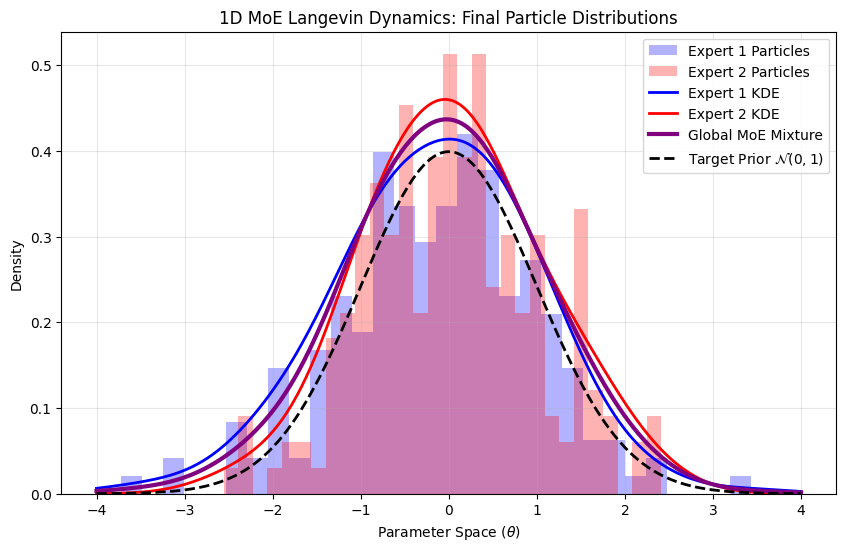

In [59]:
plt.figure(figsize=(10, 6))
x_eval = np.linspace(-4, 4, 300)

kde_1, _ = compute_kde_and_grad(x_eval, theta[0], h)
kde_2, _ = compute_kde_and_grad(x_eval, theta[1], h)
kde_moe = pi[0] * kde_1 + pi[1] * kde_2
prior = np.exp(-0.5 * x_eval**2) / np.sqrt(2 * np.pi)

plt.hist(theta[0], bins=30, alpha=0.3, density=True, color='blue', label='Expert 1 Particles')
plt.hist(theta[1], bins=30, alpha=0.3, density=True, color='red', label='Expert 2 Particles')

plt.plot(x_eval, kde_1, color='blue', linewidth=2, label='Expert 1 KDE')
plt.plot(x_eval, kde_2, color='red', linewidth=2, label='Expert 2 KDE')
plt.plot(x_eval, kde_moe, color='purple', linewidth=3, linestyle='-', label='Global MoE Mixture')
plt.plot(x_eval, prior, 'k--', linewidth=2, label='Target Prior $\mathcal{N}(0,1)$')

plt.title('1D MoE Langevin Dynamics: Final Particle Distributions')
plt.xlabel('Parameter Space ($\\theta$)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

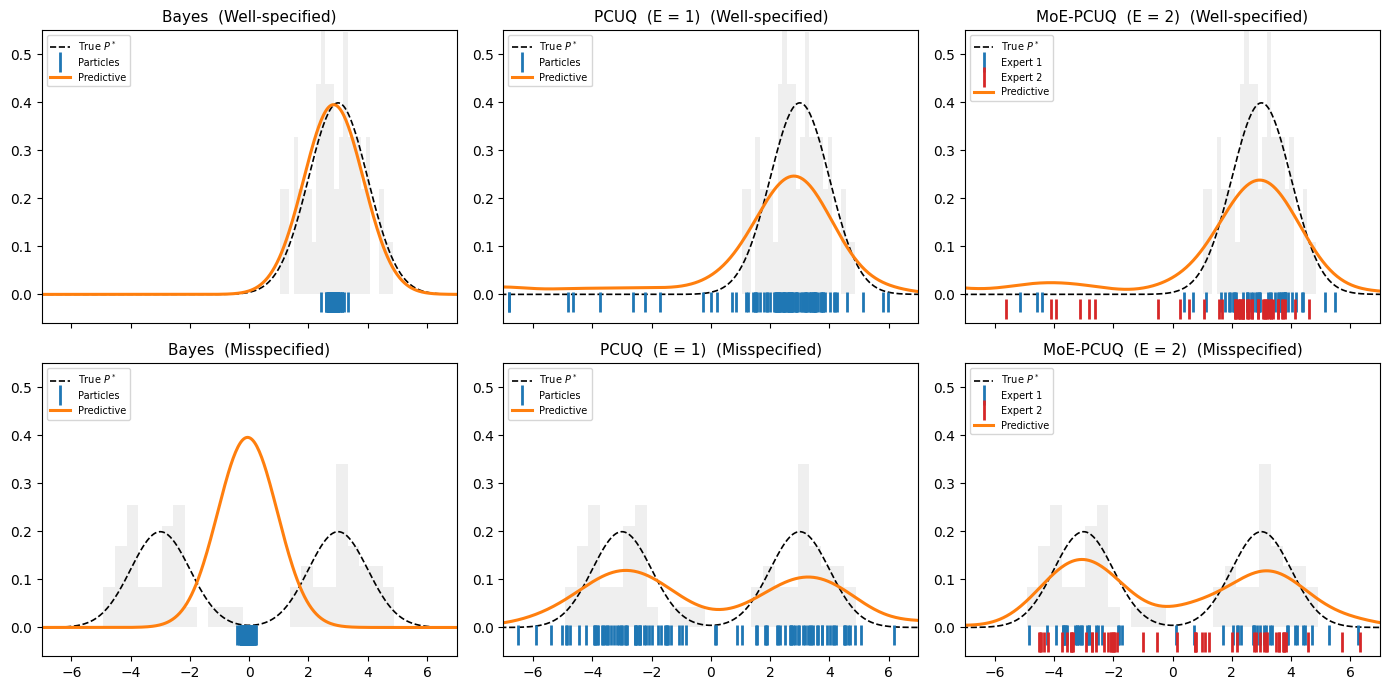

In [50]:
"""
MoE-PCUQ minimal demo.

Model family: P_theta(y) = N(y; theta, sigma^2)   (1D Gaussian, known variance)
Kernel:       k(y,y') = exp(-|y-y'|^2 / (2 ell^2)) (Gaussian on Y)

All kernel integrals analytic (PCUQ Appendix D).
Gradient flow discretised via Euler-Maruyama (PCUQ eq 9, Wild et al. eq 59).
"""
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(42)

# ── Kernel integrals (PCUQ Appendix D, p=1) ─────────────────────────

def alpha(y, th, ell, sig):
    s = ell**2 + sig**2
    return np.sqrt(ell**2 / s) * np.exp(-(y - th)**2 / (2 * s))

def grad_alpha(y, th, ell, sig):
    s = ell**2 + sig**2
    return alpha(y, th, ell, sig) * (y - th) / s

def beta(th1, th2, ell, sig):
    s = ell**2 + 2 * sig**2
    return np.sqrt(ell**2 / s) * np.exp(-(th1 - th2)**2 / (2 * s))

def grad_beta(th1, th2, ell, sig):
    s = ell**2 + 2 * sig**2
    return -beta(th1, th2, ell, sig) * (th1 - th2) / s


# ── Bayes (analytic Gaussian posterior) ──────────────────────────────

def bayes_particles(data, N, sig, sig0):
    n = len(data)
    prec_post = n / sig**2 + 1 / sig0**2
    mu_post = (data.sum() / sig**2) / prec_post
    sig_post = 1.0 / np.sqrt(prec_post)
    return np.random.randn(N) * sig_post + mu_post


# ── PCUQ  (E=1, PCUQ eq 9) ──────────────────────────────────────────

def run_pcuq(data, N, T, eta, lam, ell, sig, sig0):
    th = np.random.randn(N) * 2
    n = len(data)
    for _ in tqdm(range(T)):
        # grad_alpha: (N, n) -> mean over data -> (N,)
        ga = grad_alpha(data[None, :], th[:, None], ell, sig).mean(1)
        # grad_beta:  (N, N) with self excluded (PCUQ eq 9)
        gb = grad_beta(th[:, None], th[None, :], ell, sig)
        np.fill_diagonal(gb, 0)
        gb = gb.sum(1) / max(N - 1, 1)

        g_mmd = -ga + gb                       # Wasserstein grad of MMD²
        g_prior = -th / sig0**2                 # grad log Q0
        th -= eta * (g_mmd - lam * g_prior)     # descent
        th += np.sqrt(2 * eta * lam) * np.random.randn(N)  # Langevin noise
    return th


# ── MoE-PCUQ  (E experts, pi_e = 1/E, iid data) ────────────────────

def run_moe_pcuq(data, E, Nper, T, eta, lam, ell, sig, sig0):
    experts = [np.random.randn(Nper) * 2 for _ in range(E)]
    pi = 1.0 / E
    n = len(data)

    for _ in tqdm(range(T)):
        new = []
        for e in range(E):
            th_e = experts[e].copy()

            # ---- MMD gradient (first variation w.r.t. Q_e) ----
            # -pi_e/n  sum_i grad_alpha_i(th)
            ga = grad_alpha(data[None, :], th_e[:, None], ell, sig).mean(1)

            # +pi_e * sum_f pi_f * (1/Nf) sum_j grad_beta(th, th_{f,j})
            gb = np.zeros(Nper)
            for f in range(E):
                gb_ef = grad_beta(th_e[:, None], experts[f][None, :], ell, sig)
                if f == e:
                    np.fill_diagonal(gb_ef, 0)
                    gb += pi * gb_ef.sum(1) / max(Nper - 1, 1)
                else:
                    gb += pi * gb_ef.mean(1)

            g_mmd = pi * (-ga + gb)

            # ---- KL: prior + noise (self-entropy absorbed into diffusion) ----
            g_prior = -th_e / sig0**2

            th_e -= eta * (g_mmd - lam * pi * g_prior)
            th_e += np.sqrt(2 * eta * lam * pi) * np.random.randn(Nper)
            new.append(th_e)
        experts = new
    return experts


# ── Predictive helpers ───────────────────────────────────────────────

def pred(y, particles, sig):
    p = np.exp(-(y[:, None] - particles[None, :]) ** 2 / (2 * sig**2))
    return p.mean(1) / (np.sqrt(2 * np.pi) * sig)

def moe_pred(y, experts, sig):
    return np.mean([pred(y, ex, sig) for ex in experts], axis=0)


# ── Data ─────────────────────────────────────────────────────────────

sig = 1.0;  n = 60

data_well = np.random.randn(n) * sig + 3.0                         # N(3,1)
mix = np.random.binomial(1, 0.5, n)
data_mis  = np.where(mix, 3, -3) + np.random.randn(n) * sig        # bimodal

# ── Run ──────────────────────────────────────────────────────────────

N = 100;  E = 2;  Nper = N // E
ell = sig;  sig0 = 5.0;  lam = 0.05;  T = 4000;  eta = 0.08

results = {}
for label, data in [("well", data_well), ("mis", data_mis)]:
    results[label] = {
        "bayes": bayes_particles(data, N, sig, sig0),
        "pcuq":  run_pcuq(data, N, T, eta, lam, ell, sig, sig0),
        "moe":   run_moe_pcuq(data, E, Nper, T, eta, lam, ell, sig, sig0),
    }

# ── Plot ─────────────────────────────────────────────────────────────

y_grid = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)

titles = ["Bayes", "PCUQ  (E = 1)", "MoE-PCUQ  (E = 2)"]

for row, (label, dname) in enumerate([("well", "Well-specified"), ("mis", "Misspecified")]):
    data = data_well if label == "well" else data_mis
    # true density
    if label == "well":
        true_p = np.exp(-(y_grid - 3)**2 / 2) / np.sqrt(2*np.pi)
    else:
        true_p = 0.5 * np.exp(-(y_grid - 3)**2 / 2) / np.sqrt(2*np.pi) + \
                 0.5 * np.exp(-(y_grid + 3)**2 / 2) / np.sqrt(2*np.pi)

    for col, method in enumerate(["bayes", "pcuq", "moe"]):
        ax = axes[row, col]
        ax.hist(data, bins=25, density=True, alpha=0.25, color="silver", zorder=0)
        ax.plot(y_grid, true_p, "k--", lw=1.2, label="True $P^*$")

        r = results[label][method]
        if method == "moe":
            p = moe_pred(y_grid, r, sig)
            cols = ["tab:blue", "tab:red"]
            for e, ex in enumerate(r):
                ax.plot(ex, -0.015 * (e + 1) * np.ones_like(ex),
                        "|", ms=14, mew=2, color=cols[e],
                        label=f"Expert {e+1}")
        else:
            p = pred(y_grid, r, sig)
            ax.plot(r, -0.015 * np.ones_like(r),
                    "|", ms=14, mew=2, color="tab:blue", label="Particles")

        ax.plot(y_grid, p, color="tab:orange", lw=2.2, label="Predictive")
        ax.set_title(f"{titles[col]}  ({dname})", fontsize=11)
        ax.set_xlim(-7, 7);  ax.set_ylim(-0.06, 0.55)
        ax.legend(fontsize=7, loc="upper left")

fig.tight_layout()
# fig.savefig("/mnt/user-data/outputs/moe_pcuq_demo.png", dpi=150, bbox_inches="tight")
# print("saved.")
plt.show()

$$\begin{align*}
\delta_{e,i} = \frac{\partial \mathcal{L}}{\partial w_e(x_i)} &= \frac{1}{n} \Bigg[ \underbrace{ \sum_{f=1}^E \pi_f \left( \frac{1}{n_e n_f} \sum_{p=1}^{n_e} \sum_{q=1}^{n_f} k(\theta_{e,p}, \vartheta_{f,q}) \right) - \frac{1}{n_e} \sum_{p=1}^{n_e} k(x_i, \theta_{e,p}) }_{\text{MMD Routing Forces}} \\
&\quad + \underbrace{ \lambda_n \frac{1}{n_e} \sum_{p=1}^{n_e} \left( \log \frac{\tilde{Q}_{MoE}(\theta_{e,p})}{Q_0(\theta_{e,p})} + 1 \right) }_{\text{KL Penalty}} \\
&\quad + \underbrace{ \lambda_1 (\log \pi_e + 1) - \lambda_2 (\log w_e(x_i) + 1) }_{\text{Routing Regularizers}} \Bigg]
\end{align*}$$

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0 | Gate Splitting Ratio: 0.79 / 0.21
Epoch 200 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 400 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 600 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 800 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1000 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1200 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1400 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1600 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1800 | Gate Splitting Ratio: 0.50 / 0.50


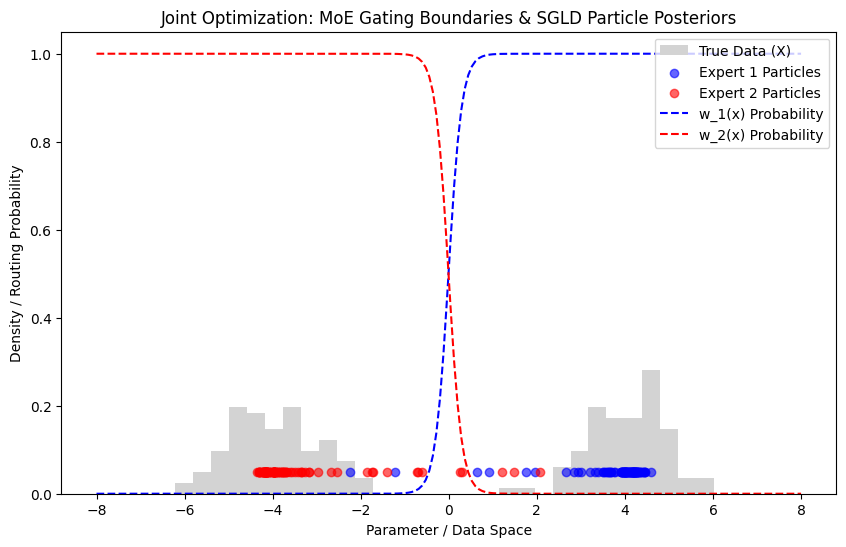

In [72]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup & Hyperparameters
# ==========================================
torch.manual_seed(42)

# Training params
n_epochs = 2000
n_particles = 100         # Particles per expert
lr_particles = 0.05      # eta for SGLD
lr_gate = 0.05           # Learning rate for Adam
lambda_prior = 0.001       # KL Prior strength
lambda_entropy = 0.1     # Load balancing penalty

# Generate Toy Data: Two distinct clusters at -4 and +4
X_data = torch.cat([
    torch.randn(100, 1) - 4.0, 
    torch.randn(100, 1) + 4.0
])
N_data = X_data.shape[0]

# Initialize Particles for 2 Experts (requires_grad=True for SGLD)
# We initialize them randomly near the center
theta_1 = (torch.randn(n_particles, 1) - 0.0).requires_grad_(True)
theta_2 = (torch.randn(n_particles, 1) + 0.0).requires_grad_(True)

# Define the Gating Network (Soft Boundaries)
gate_net = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 2),
    nn.Softmax(dim=1) # Outputs [w_1(x), w_2(x)]
)
gate_optimizer = torch.optim.Adam(gate_net.parameters(), lr=lr_gate)

# ==========================================
# 2. The MMD / Kernel Functions
# ==========================================
def rbf_kernel(X, Y, h=15.0):
    """Standard RBF Kernel: exp(-||x-y||^2 / h)"""
    XX = (X ** 2).sum(dim=1, keepdim=True)
    YY = (Y ** 2).sum(dim=1, keepdim=True)
    dist = XX + YY.t() - 2 * X @ Y.t()
    return torch.exp(-dist / h)

def compute_mmd_loss(X, theta_1, theta_2, gate_weights):
    """
    Computes the PCUQ MoE MMD exactly as derived in your 'MoE Dynamics' doc.
    gate_weights shape: [N_data, 2]
    """
    # Average routing weights across the dataset (pi_e)
    pi_1 = gate_weights[:, 0].mean()
    pi_2 = gate_weights[:, 1].mean()
    
    # 1. Model-to-Model Interaction (The Block Diagonal Approximation)
    # Note: We decouple the experts here to get the O(E * n^2) shortcut!
    k_11 = rbf_kernel(theta_1, theta_1).mean()
    k_22 = rbf_kernel(theta_2, theta_2).mean()
    model_interaction = (pi_1**2 * k_11) + (pi_2**2 * k_22)
    
    # 2. Data-to-Model Interaction (The Routing Forces)
    k_X1 = rbf_kernel(X, theta_1).mean(dim=1) # shape [N_data]
    k_X2 = rbf_kernel(X, theta_2).mean(dim=1) # shape [N_data]
    
    # Weight the kernel interactions by the gate probabilities for each point
    data_interaction = (gate_weights[:, 0] * k_X1).mean() + \
                       (gate_weights[:, 1] * k_X2).mean()
    
    # 3. Data-to-Data (Constant, so we ignore it for optimization)
    # MMD^2 = Model_Interaction - 2 * Data_Interaction
    return model_interaction - 2 * data_interaction

# ==========================================
# 3. The Alternating Joint Training Loop
# ==========================================
for epoch in tqdm(range(n_epochs)):
    
    # Forward pass: Get routing weights for the batch
    gate_weights = gate_net(X_data) 
    pi_1 = gate_weights[:, 0].mean().item()
    pi_2 = gate_weights[:, 1].mean().item()
    
    # ---------------------------------------------------------
    # PHASE A: Update Particles (SGLD) - Freezing the Gate
    # ---------------------------------------------------------
    # 1. Compute the exact MMD spatial gradients via autograd
    loss_mmd = compute_mmd_loss(X_data, theta_1, theta_2, gate_weights.detach())
    loss_mmd.backward()
    
    with torch.no_grad(): # Apply the physical update rules manually
        for idx, (theta_e, pi_e) in enumerate([(theta_1, pi_1), (theta_2, pi_2)]):
            
            # THE FIX: Scale the PyTorch gradient back to the theoretical Expectation
            force_mmd = -theta_e.grad * (n_particles / 2.0)
            
            # The Prior Drift (Standard Gaussian N(0,1) weight decay)
            force_prior = -theta_e 
            
            # Combine drifts 
            drift = force_mmd + (lambda_prior * pi_e * force_prior)
            
            # The SGLD Noise 
            noise_scale = torch.sqrt(torch.tensor(2 * lr_particles * lambda_prior * pi_e))
            noise = noise_scale * torch.randn_like(theta_e)
            
            # SGLD Step
            theta_e.add_(lr_particles * drift + noise)
            
            # Zero out gradients for the next loop
            theta_e.grad.zero_()
    # ---------------------------------------------------------
    # PHASE B: Update Gate (Adam) - Freezing the Particles
    # ---------------------------------------------------------
    gate_optimizer.zero_grad()
    
    # 1. Recompute MMD loss with detached particles to get routing error signal
    loss_gate_mmd = compute_mmd_loss(X_data, theta_1.detach(), theta_2.detach(), gate_weights)
    
    # 2. Add Load Balancing (Marginal Entropy) to prevent Routing Collapse
    # This matches your "MoE MMD Architectural Crossroads" document
    pi_tensor = gate_weights.mean(dim=0) 
    loss_entropy = - torch.sum(pi_tensor * torch.log(pi_tensor + 1e-8))
    
    # Total Gate Loss
    total_gate_loss = loss_gate_mmd - (lambda_entropy * loss_entropy)
    
    # Backpropagate through the neural network and update weights
    total_gate_loss.backward()
    gate_optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Gate Splitting Ratio: {pi_1:.2f} / {pi_2:.2f}")

# ==========================================
# 4. Visualization
# ==========================================
with torch.no_grad():
    # Plotting the data and particles
    plt.figure(figsize=(10, 6))
    plt.hist(X_data.numpy(), bins=30, density=True, color='lightgray', label='True Data (X)')
    
    # Plot Expert 1 Posterior
    plt.scatter(theta_1.numpy(), [0.05]*n_particles, color='blue', alpha=0.6, label='Expert 1 Particles')
    
    # Plot Expert 2 Posterior
    plt.scatter(theta_2.numpy(), [0.05]*n_particles, color='red', alpha=0.6, label='Expert 2 Particles')
    
    # Plot the Gating Network's Decision Boundary
    x_range = torch.linspace(-8, 8, 200).unsqueeze(1)
    gate_probs = gate_net(x_range)
    plt.plot(x_range.numpy(), gate_probs[:, 0].numpy(), color='blue', linestyle='--', label='w_1(x) Probability')
    plt.plot(x_range.numpy(), gate_probs[:, 1].numpy(), color='red', linestyle='--', label='w_2(x) Probability')

    plt.title('Joint Optimization: MoE Gating Boundaries & SGLD Particle Posteriors')
    plt.xlabel('Parameter / Data Space')
    plt.ylabel('Density / Routing Probability')
    plt.legend(loc='upper right')
    plt.show()